# Day 8 — Side-by-Side Maps: Raw Count vs Rate

**Theme:** The same data tells two different stories depending on how you measure it. Showing both maps together makes the difference impossible to miss.

**No new data today** — everything comes from files you already have.

**By the end of this notebook you will have:**
- Rebuilt the complaint choropleth from Day 5 (raw count)
- Added the normalized rate from Day 7 to the same GeoDataFrame
- Plotted both maps side by side on one figure
- Written a one-paragraph interpretation of what changed

**New skill:** `plt.subplots(1, 2)` — creates two map panels on the same canvas, side by side.

**No hints unless you ask.**

In [2]:
# Imports: pandas, geopandas, matplotlib.pyplot

import pandas as pd, geopandas as gpd, matplotlib.pyplot as plt


In [11]:
# Rebuild everything you need. You have done all of this before.
#
# From 311_cleaned.csv:
#   complaint_count — grouped by Incident Zip

df2 = pd.read_csv('../data/311_cleaned.csv')
df1 = pd.read_csv('../data/pluto.csv')
gdf = gpd.read_file('../data/nyczipcodes.geojson')
gdf['modzcta'] = pd.to_numeric(gdf['modzcta'], errors='coerce').astype(float)
df_acs = pd.read_csv('../data/zip_data_2024.csv', skiprows=[1])

complaint_count = df2.groupby('Incident Zip').size().reset_index(name='complaint_count')


df_acs['B01003_001E'] = pd.to_numeric(df_acs['B01003_001E'], errors='coerce')

df_acs = df_acs.rename(columns={'B01003_001E': 'population'})



# Drops rows where 'my_column' is NaN OR 0
# The '~' means "NOT", keeping rows that don't match the condition
df_acs = df_acs[~(df_acs['population'].isna() | (df_acs['population'] == 0))]

#print(df_acs)

# 1. Load
df_acs = pd.read_csv('../data/zip_data_2024.csv', skiprows=[1])

# 2. Extract and filter zip codes FIRST
df_acs['zipcode'] = df_acs['NAME'].str.replace('ZCTA5 ', '').str.strip()
df_acs = df_acs[df_acs['zipcode'].str.startswith('112', na=False)]

# 3. Clean population
df_acs['B01003_001E'] = pd.to_numeric(df_acs['B01003_001E'], errors='coerce')
df_acs = df_acs.rename(columns={'B01003_001E': 'population'})
df_acs = df_acs[~(df_acs['population'].isna() | (df_acs['population'] == 0))]

# 4. Convert zipcode to float for merging
df_acs['zipcode'] = pd.to_numeric(df_acs['zipcode'], errors='coerce').astype(float)

# 5. Now merge
df_rates = pd.merge(complaint_count, df_acs, left_on='Incident Zip', right_on='zipcode')
df_rates['complaints_per_1k'] = (df_rates['complaint_count'] / df_rates['population']) * 1000


#print(df_rates)

df_rates['complaints_per_1k'] = (df_rates['complaint_count'] / df_rates['population']) * 1000
#
# From zip_data_2024.csv (ACS):
#   df_acs — load, skip label row, extract zipcode, filter to 112xx,
#             convert population to numeric, rename B01003_001E to population
#

# Merge complaint_count + df_acs → df_rates
# Calculate df_rates['complaints_per_1k']
df_acs['zipcode'] = df_acs['NAME'].str.replace('ZCTA5 ', '').str.strip()
df_acs = df_acs[df_acs['zipcode'].str.startswith('112', na=False)]
df_acs['zipcode'] = pd.to_numeric(df_acs['zipcode'], errors='coerce').astype(float)


#
# From nyc_zipcodes.geojson:
#   gdf — zip code boundaries

#
# Merge gdf + complaint_count → gdf_merged (raw count on the shapes)
# Merge gdf_merged + df_rates → gdf_full (adds complaints_per_1k to the shapes)

gdf_merged = pd.merge(gdf,complaint_count, left_on='modzcta', right_on='Incident Zip')
#
# That final gdf_full is what you plot.

gdf_full = pd.merge(gdf_merged, df_rates, on='Incident Zip')

print(gdf_full)



/var/folders/01/7mmm8p_55mz_znpc8yd21gjc0000gn/T/ipykernel_53791/1406347303.py:7: DtypeWarning: Columns (0: zonedist3, 1: zonedist4, 2: overlay2, 3: spdist1, 4: spdist2, 5: ltdheight, 6: splitzone, 7: unitsres, 8: unitstotal, 9: lotfront, 10: lotdepth, 11: bldgfront, 12: bldgdepth, 13: irrlotcode, 14: histdist, 15: landmark, 16: condono, 17: edesignum, 18: dcpedited, 19: mihopt1, 20: mihopt2, 21: mihopt3, 22: mihopt4) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv('../data/pluto.csv')


                   :id           :version                      :created_at  \
0   row-huf4~2hg5_z872  rv-v6tk~xk99.f44y 2020-05-13 23:28:10.857000+00:00   
1   row-gmjh_pzhm-3782  rv-wpxa-tjn6.rnda 2020-05-13 23:28:10.857000+00:00   
2   row-9ube-k8t6_bvhe  rv-2acz.jwec.xuuq 2020-05-13 23:28:10.857000+00:00   
3   row-tq4a_2vir_kzfz  rv-b92e.97mw-u75e 2020-05-13 23:28:10.857000+00:00   
4   row-4ewt~9r74-vk99  rv-4nsg-rfse-s6t4 2020-05-13 23:28:10.857000+00:00   
5   row-qj7r_7i8n-xvnr  rv-kxzd_tcen-ihh7 2020-05-13 23:28:10.857000+00:00   
6   row-aqfq-man2_py7e  rv-nwzz~3vru.jvwa 2020-05-13 23:28:10.857000+00:00   
7   row-p6hu_25f9~8myt  rv-tjqq.76rh-eee6 2020-05-13 23:28:10.857000+00:00   
8   row-suwm_954v.pnd2  rv-z8z8-n3mc-5f8i 2020-05-13 23:28:10.857000+00:00   
9   row-4dsg_smqi-75gu  rv-2vxw~x4wg~v2da 2020-05-13 23:28:10.857000+00:00   
10  row-wzcb_fmrp_pcm9  rv-wbz8.ayxz~nkdx 2020-05-13 23:28:10.857000+00:00   
11  row-ripv.9ii5_ypfe  rv-gnw7-2edj_gic3 2020-05-13 23:28:10.85

In [ ]:
# Sanity check before plotting.
# Print gdf_full.columns and confirm both complaint_count and complaints_per_1k are in there.
# Print len(gdf_full) — should be roughly 40 Brooklyn zip codes.

print(len(gdf_full))



37


## Step 1 — Side-by-side figure

`plt.subplots(1, 2)` creates a figure with 1 row and 2 columns of panels.
It returns two things: the figure object and an array of axes.

```python
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
```

- `ax1` is the left panel
- `ax2` is the right panel
- Pass `ax=ax1` or `ax=ax2` to `.plot()` to control which panel each map goes into

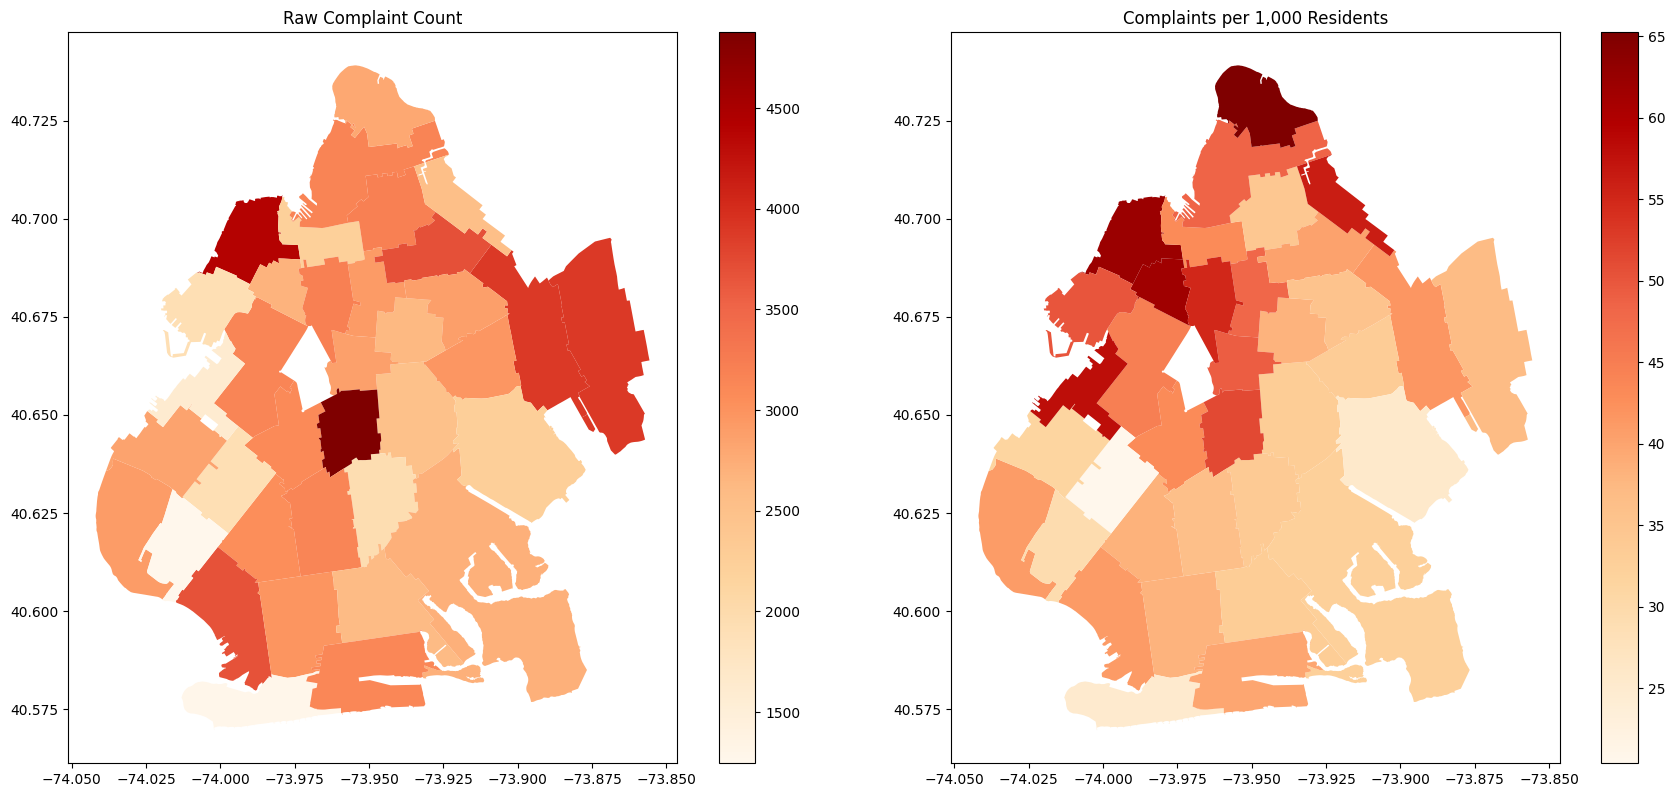

In [22]:
# Create the side-by-side figure.
# Left panel (ax1): choropleth shaded by complaint_count
# Right panel (ax2): choropleth shaded by complaints_per_1k
# Use the same cmap for both so colors are comparable: 'OrRd'
# Add a title to each panel using ax1.set_title() and ax2.set_title()
# plt.tight_layout() prevents overlap
# plt.show() at the end

gdf_plot = gdf_full[gdf_full['Incident Zip'] != 11239.0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

gdf_plot.plot(column='complaint_count_x', cmap='OrRd', legend=True, ax=ax1)
ax1.set_title('Raw Complaint Count')

gdf_plot.plot(column='complaints_per_1k', cmap='OrRd', legend=True, ax=ax2)
ax2.set_title('Complaints per 1,000 Residents')

plt.tight_layout()
plt.show()



## Step 2 — Read the maps

Look at both panels side by side and answer these questions in the markdown cell below:

1. Which zip codes are darkest on the left (raw count) but lighter on the right (rate)?
2. Which zip codes are lighter on the left but darker on the right?
3. What does that flip tell you about those neighborhoods?
4. If you were a city planner deciding where to target housing inspections, which map would you use — and why?

*(Your observations here)*

1. I immediately notice the the flat bush zip code in south prospect park is deeply red for raw count but not that red for per 1000 residents. Same deal as east new york zip code, i find that it also red but gets lighter when you adjust per 10000
2. Greenpoint gets significantly darker when you adjust per 1000 people, and so do neighborhoods in downtown brooklyn. 

3. Noting that they don't have that many residents per say but a lot of those residents make 311 calls more than some other zip codes that may have more people

4. I'm a bit torn, I'm more compelled to go off of the raw complaint counts. Yes per 1000 people resdients in downtown brooklyn and greenpoint have more complaints to 311 but I just think because a lot more people are aware, have the time, and seen 311 actually do their job compared to places like Flatbush and East New York, which have higher populations so more 311 calls, but being that these areas tend to also be poorer I'm assuming that these 311 calls they are making are much higher need than more affluent area, despite a lower rate per 1000. 

## Day 8 Recap

| What you did | Why it matters |
|---|---|
| `plt.subplots(1, 2)` | Standard pattern for any multi-panel figure |
| Same cmap on both maps | Makes color shading directly comparable |
| Side-by-side comparison | The visual equivalent of the ranking flip you found on Day 7 |
| Written interpretation | A map without a caption is just a picture — the analysis is in the words |

### What's coming on Day 9

We move to **ACRIS** — NYC deed and mortgage records. You'll pull sale prices for properties in Bushwick and calculate actual cap rates from real transaction data, not hypothetical numbers.